In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import cobra
from cobra.io import read_sbml_model
from cobra import Model as CobraModel
import ast
import random
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize, LabelEncoder, MinMaxScaler
import matplotlib.colors as mcolors

In [3]:
def extract_and_plot_coefficients(function_result, step=10): #function_result: the result of optimize_objective_from_qualitative_criteria_agreement function
    # Get reaction IDs from the first iteration
    reaction_ids = list(function_result[0].keys())
    
    # Initialize dictionary to store coefficients for each reaction
    coeff_dict = {rid: [] for rid in reaction_ids}

    # Collect coefficients from each iteration
    for row in function_result[2].iloc[:, 0]:
        for i, rid in enumerate(reaction_ids):
            coeff_dict[rid].append(row[i])

    # Plotting
    num_reactions = len(reaction_ids)
    num_rows = (num_reactions + 1) // 2
    fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(14, 4 * num_rows))
    axes = axes.flatten()

    x_axis = list(range(0, len(function_result[2]), step))

    colors = ['black', 'blue', 'red', 'green', 'purple', 'brown', 'orange', 'cyan']

    for i, rid in enumerate(reaction_ids):
        ax = axes[i]
        ax.plot(x_axis, coeff_dict[rid][::step], marker='o', linestyle='-', color=colors[i % len(colors)])
        reaction_name = model.reactions.get_by_id(rid).name
        ax.set_title(f'{rid}: {reaction_name}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Coefficient in objective function')
        ax.grid(True)
        ax.axhline(0, color='orange', linestyle='--', linewidth=2)
        ax.set_ylim(-1, 1)

    # Hide any unused subplots
    for j in range(num_reactions, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [4]:
def plot_boxplots_of_100pct_solutions(df, reaction_ids):
    # Map reaction IDs to names
    reaction_names = {}
    for r in reaction_ids:
        reaction_names[r] = model.reactions.get_by_id(r).name

    # Ensure coefficients column is properly parsed
    df['coefficients'] = df['coefficients'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

    # Filter for 100% accuracy
    df_100 = df[df['accuracy'] == 1.0]

    # Extract coefficient data for each reaction
    data = []
    means = []
    for i, rid in enumerate(reaction_ids):
        coeffs = [row[i] for row in df_100['coefficients']]
        data.append(coeffs)
        means.append(np.mean(coeffs))

    # Set up plot
    labels = [f"{rid}: {reaction_names[rid]}" for rid in reaction_ids]
    plt.figure(figsize=(5, 5))
    box_colors = ['black', 'red', 'blue', 'green', 'purple', 'brown', 'orange', 'cyan']

    box = plt.boxplot(
        data,
        patch_artist=True,
        labels=labels,
        boxprops=dict(color='black'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black')
    )

    # Color each box
    for patch, color in zip(box['boxes'], box_colors):
        patch.set_facecolor(color)
        
     # Add mean text
    for i, mean in enumerate(means):
        label = f"{mean:.3f}"
        plt.text(
            i + 1.25,   # slightly right of the box (1 = box center)
            mean,       # y-position
            label,
            va='center',
            ha='left',
            fontsize=11,
            color='black'
        )
    plt.ylim(-1, 1)
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Aesthetics
    plt.xticks(fontsize=12,rotation=45)
    plt.yticks(fontsize=12)
    plt.ylabel("Coefficient Value", fontsize=12)
    plt.tight_layout()
    plt.savefig('coeff_boxplot_fast_211125_6.png', dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
#in another notebook, simoff was editted to remove the break line when the first instance of 100% accuracy was found
model = read_sbml_model('yeast-GEM.xml')

%store -r slow_combinations_no_dropout
%store -r fast_combinations_no_dropout

#how many solutions for either simoff run reached 100% accuracy?
accurate_df_slow = slow_combinations_no_dropout[2][slow_combinations_no_dropout[2]['accuracy'] == 1.0]
print('number of solutions for slower growing yeast simoff that reached 100%:',len(accurate_df_slow))
accurate_df_fast = fast_combinations_no_dropout[2][fast_combinations_no_dropout[2]['accuracy'] == 1.0]
print('number of solutions for faster growing yeast simoff that reached 100%:',len(accurate_df_fast))

number of solutions for slower growing yeast simoff that reached 100%: 415
number of solutions for faster growing yeast simoff that reached 100%: 19


### Figure 5a

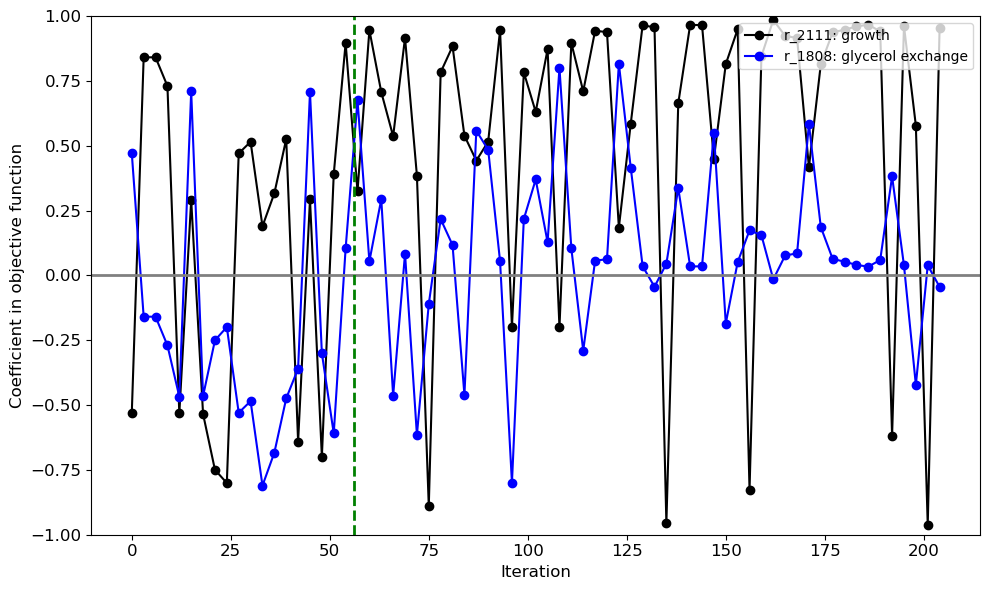

In [9]:
for n in range(len(fast_combinations_no_dropout[2])):
    if fast_combinations_no_dropout[2].iloc[n,1] == 1.0:
        fast_first_instance = n
        break

reaction_ids = []
for k,v in fast_combinations_no_dropout[0].items():
    reaction_ids.append(k)
    
    # Initialize dictionary to store coefficients for each reaction
coeff_dict = {rid: [] for rid in reaction_ids}

    # Collect coefficients from each iteration
for row in fast_combinations_no_dropout[2].iloc[:, 0]:
    for i, rid in enumerate(reaction_ids):
        coeff_dict[rid].append(row[i])

x_axis = list(range(0, len(fast_combinations_no_dropout[2]), 3))

step = 3
intercept_x = fast_first_instance  # x-position of vertical intercept line

plt.figure(figsize=(10, 6))
colors = ['black', 'blue', 'red', 'green', 'purple', 'brown', 'orange', 'cyan']
x_axis = list(range(0, len(next(iter(coeff_dict.values()))), step))

for i, rid in enumerate(reaction_ids):
    y_values = coeff_dict[rid][::step]
    reaction_name = model.reactions.get_by_id(rid).name
    plt.plot(x_axis, y_values, marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'{rid}: {reaction_name}')

plt.axhline(0, color='gray', linestyle='-', linewidth=2)
plt.axvline(x=intercept_x, color='green', linestyle='--', linewidth=2)

plt.xlabel('Iteration',fontsize=12)
plt.ylabel('Coefficient in objective function',fontsize=12)
plt.ylim(-1, 1)
plt.legend(loc='upper right')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
#plt.savefig('coefficients_combined_fast_211125_2.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 5b

C:\Users\p04121km\AppData\Local\Temp\ipykernel_19716\3136507397.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['coefficients'] = df['coefficients'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
C:\Users\p04121km\AppData\Local\Temp\ipykernel_19716\3136507397.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


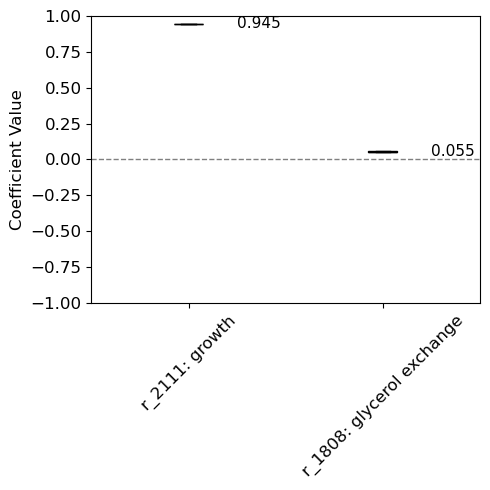

In [10]:
reaction_ids = []
for k,v in fast_combinations_no_dropout[0].items():
    reaction_ids.append(k)
plot_boxplots_of_100pct_solutions(accurate_df_fast, reaction_ids)

### Figure 5c

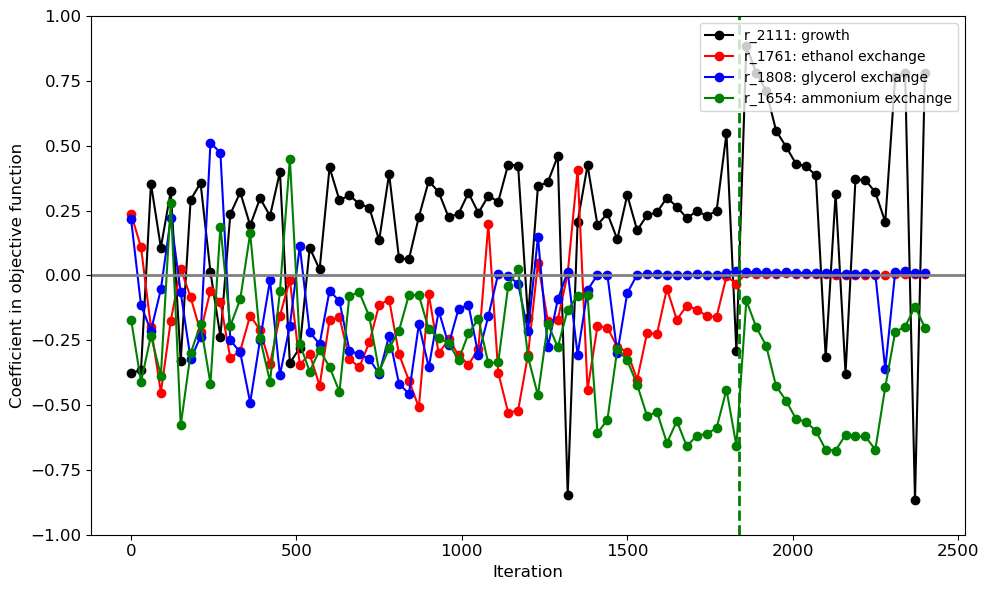

In [13]:
for n in range(len(slow_combinations_no_dropout[2])):
    if slow_combinations_no_dropout[2].iloc[n,1] == 1.0:
        slow_first_instance = n
        break

reaction_ids = []
for k,v in slow_combinations_no_dropout[0].items():
    reaction_ids.append(k)
    
    # Initialize dictionary to store coefficients for each reaction
coeff_dict = {rid: [] for rid in reaction_ids}

    # Collect coefficients from each iteration
for row in slow_combinations_no_dropout[2].iloc[:, 0]:
    for i, rid in enumerate(reaction_ids):
        coeff_dict[rid].append(row[i])

x_axis = list(range(0, len(slow_combinations_no_dropout[2]), 30))

step = 30
intercept_x = slow_first_instance  # x-position of vertical intercept line

plt.figure(figsize=(10, 6))
colors = ['black', 'red', 'blue', 'green', 'purple', 'brown', 'orange', 'cyan']
x_axis = list(range(0, len(next(iter(coeff_dict.values()))), step))

for i, rid in enumerate(reaction_ids):
    y_values = coeff_dict[rid][::step]
    reaction_name = model.reactions.get_by_id(rid).name
    plt.plot(x_axis, y_values, marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'{rid}: {reaction_name}')

plt.axhline(0, color='gray', linestyle='-', linewidth=2)
plt.axvline(x=intercept_x, color='green', linestyle='--', linewidth=2)

plt.xlabel('Iteration',fontsize=12)
plt.ylabel('Coefficient in objective function',fontsize=12)
plt.ylim(-1, 1)
plt.legend(loc='upper right')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
#plt.savefig('coefficients_combined_slow_211125_2.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 5d

C:\Users\p04121km\AppData\Local\Temp\ipykernel_19716\3136507397.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['coefficients'] = df['coefficients'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
C:\Users\p04121km\AppData\Local\Temp\ipykernel_19716\3136507397.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


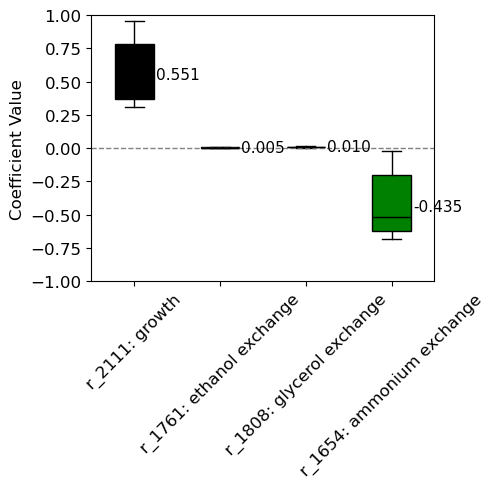

In [14]:
plot_boxplots_of_100pct_solutions(accurate_df_slow, reaction_ids)